# 03 — Feature Engineering: Engagement (Qiqi)
**Tujuan:** Membuat fitur interaksi penonton (like, comment, retention) untuk mengukur kualitas konten.  
**Output:** `data/processed/features_engagement.csv`  
**Digunakan oleh:** M1-Regression, M3-Anomaly, M4-RootCause, M5-Clustering

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
print("Libraries loaded ✓")

Libraries loaded ✓


In [3]:
# ── 1. LOAD DATA ─────────────────────────────────────────────────────────────
df = pd.read_csv('../../data/cleaned/abis_cleaning.csv')
df = df.drop_duplicates(subset=['video_id'], keep='first').reset_index(drop=True)

df['views']            = df['penayangan_tak_dilewati']
df['likes']            = df['suka']
df['dislikes']         = df['tidak_suka']
df['comments']         = df['komentar_ditambahkan']
df['avg_view_pct']     = df['persentase_penayangan_rata_rata']  # retention %

def time_to_sec(t):
    try:
        if pd.isna(t): return 0
        parts = str(t).split(':')
        if len(parts)==3: return int(parts[0])*3600+int(parts[1])*60+int(parts[2])
        if len(parts)==2: return int(parts[0])*60+int(parts[1])
        return float(t)
    except: return 0

df['avg_view_dur_sec'] = df['rata_rata_durasi_tonton'].apply(time_to_sec)
df['video_dur_sec']    = df['durasi']

print(f"Shape: {df.shape}")
print(df[['views','likes','dislikes','comments','avg_view_pct','avg_view_dur_sec']].describe().round(2))

Shape: (2355, 55)
            views     likes  dislikes  comments  avg_view_pct  \
count     2355.00   2355.00   2355.00   2355.00       2355.00   
mean     42805.18    472.44     12.83    190.05         38.68   
std      95498.31   1012.73     29.12    360.05         11.51   
min         19.00      0.00      0.00      0.00          1.16   
25%       4915.00     88.00      2.00     25.00         33.16   
50%      12755.00    195.00      5.00     69.00         37.51   
75%      37527.00    482.50     11.00    193.50         41.48   
max    1515626.00  21430.00    456.00   4903.00        181.25   

       avg_view_dur_sec  
count           2355.00  
mean             210.47  
std               53.24  
min               25.00  
25%              189.00  
50%              214.00  
75%              238.00  
max              751.00  


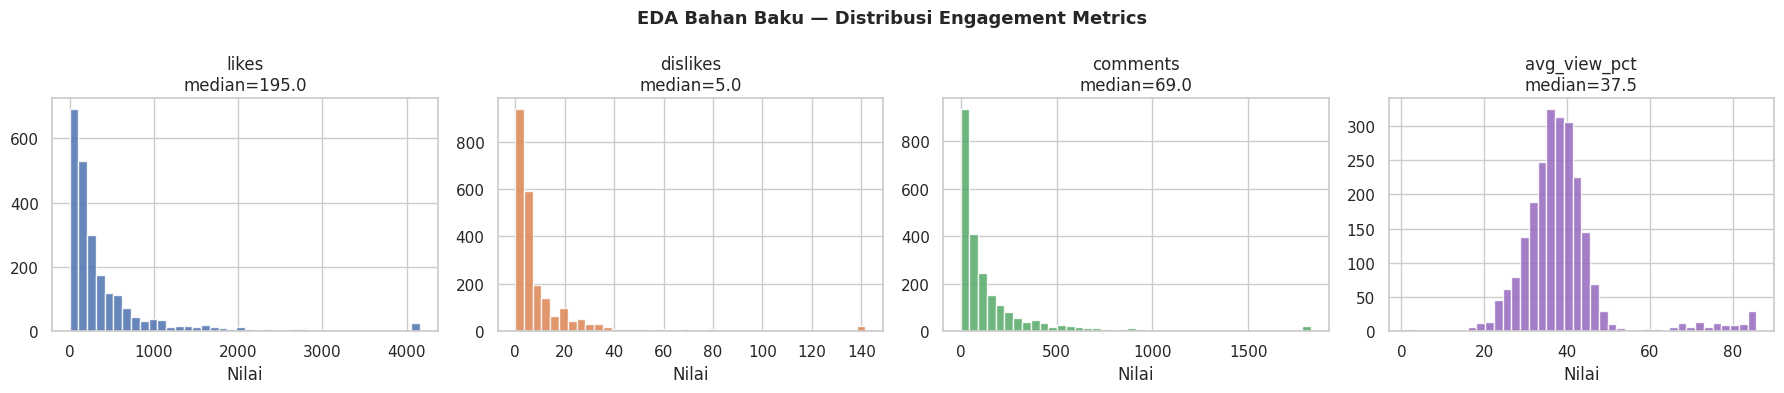

Missing values:
likes               0
dislikes            0
comments            0
avg_view_pct        0
avg_view_dur_sec    0
dtype: int64


In [4]:
# ── 2. EDA BAHAN BAKU ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('EDA Bahan Baku — Distribusi Engagement Metrics', fontsize=13, fontweight='bold')

for ax, col, color in zip(axes,
    ['likes','dislikes','comments','avg_view_pct'],
    ['#4C72B0','#DD8452','#55A868','#9467BD']):
    vals = df[col].dropna().clip(0, df[col].quantile(0.99))
    ax.hist(vals, bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'{col}\nmedian={df[col].median():.1f}')
    ax.set_xlabel('Nilai')

plt.tight_layout()
plt.show()

print("Missing values:")
print(df[['likes','dislikes','comments','avg_view_pct','avg_view_dur_sec']].isnull().sum())

In [6]:
# ── 3. FEATURE COMPUTATION ───────────────────────────────────────────────────
EPS = 1  # hindari pembagian nol

# Rate dasar
df['like_rate']    = df['likes']    / (df['views'] + EPS)
df['dislike_rate'] = df['dislikes'] / (df['views'] + EPS)
df['comment_rate'] = df['comments'] / (df['views'] + EPS)

# Rasio kualitas
df['like_dislike_ratio']     = df['likes'] / (df['dislikes'] + EPS)
df['comment_engagement_ratio'] = df['comments'] / (df['likes'] + EPS)

# Retention proxy: avg_view_dur / video_dur (capped 0-1)
df['retention_proxy'] = (df['avg_view_dur_sec'] / (df['video_dur_sec'] + EPS)).clip(0, 1)

# Fallback jika video_dur_sec = 0, gunakan avg_view_pct
mask = df['video_dur_sec'] == 0
df.loc[mask, 'retention_proxy'] = df.loc[mask, 'avg_view_pct'] / 100

# Engagement score (weighted)
df['engagement_score'] = (
    df['like_rate']    * 0.40 +
    df['comment_rate'] * 0.30 +
    df['retention_proxy'] * 0.30
)

# Engagement quality (penonton aktif + tahan lama)
df['engagement_quality'] = df['engagement_score'] * df['retention_proxy']

print("Engagement features computed ✓")
df[['like_rate','dislike_rate','comment_rate','retention_proxy','engagement_score']].describe().round(4)

Engagement features computed ✓


,like_rate,dislike_rate,comment_rate,retention_proxy,engagement_score
count,2355.0000,2355.0000,2355.0000,2355.0000,2355.0000
mean,0.0166,0.0005,0.0066,0.3850,0.1241
std,0.0085,0.0005,0.0056,0.1102,0.0348
min,0.0000,0.0000,0.0000,0.0116,0.0082
25%,0.0109,0.0002,0.0029,0.3306,0.1066
50%,0.0147,0.0003,0.0050,0.3740,0.1200
75%,0.0200,0.0005,0.0086,0.4137,0.1330
max,0.0738,0.0057,0.0517,1.0000,0.3219


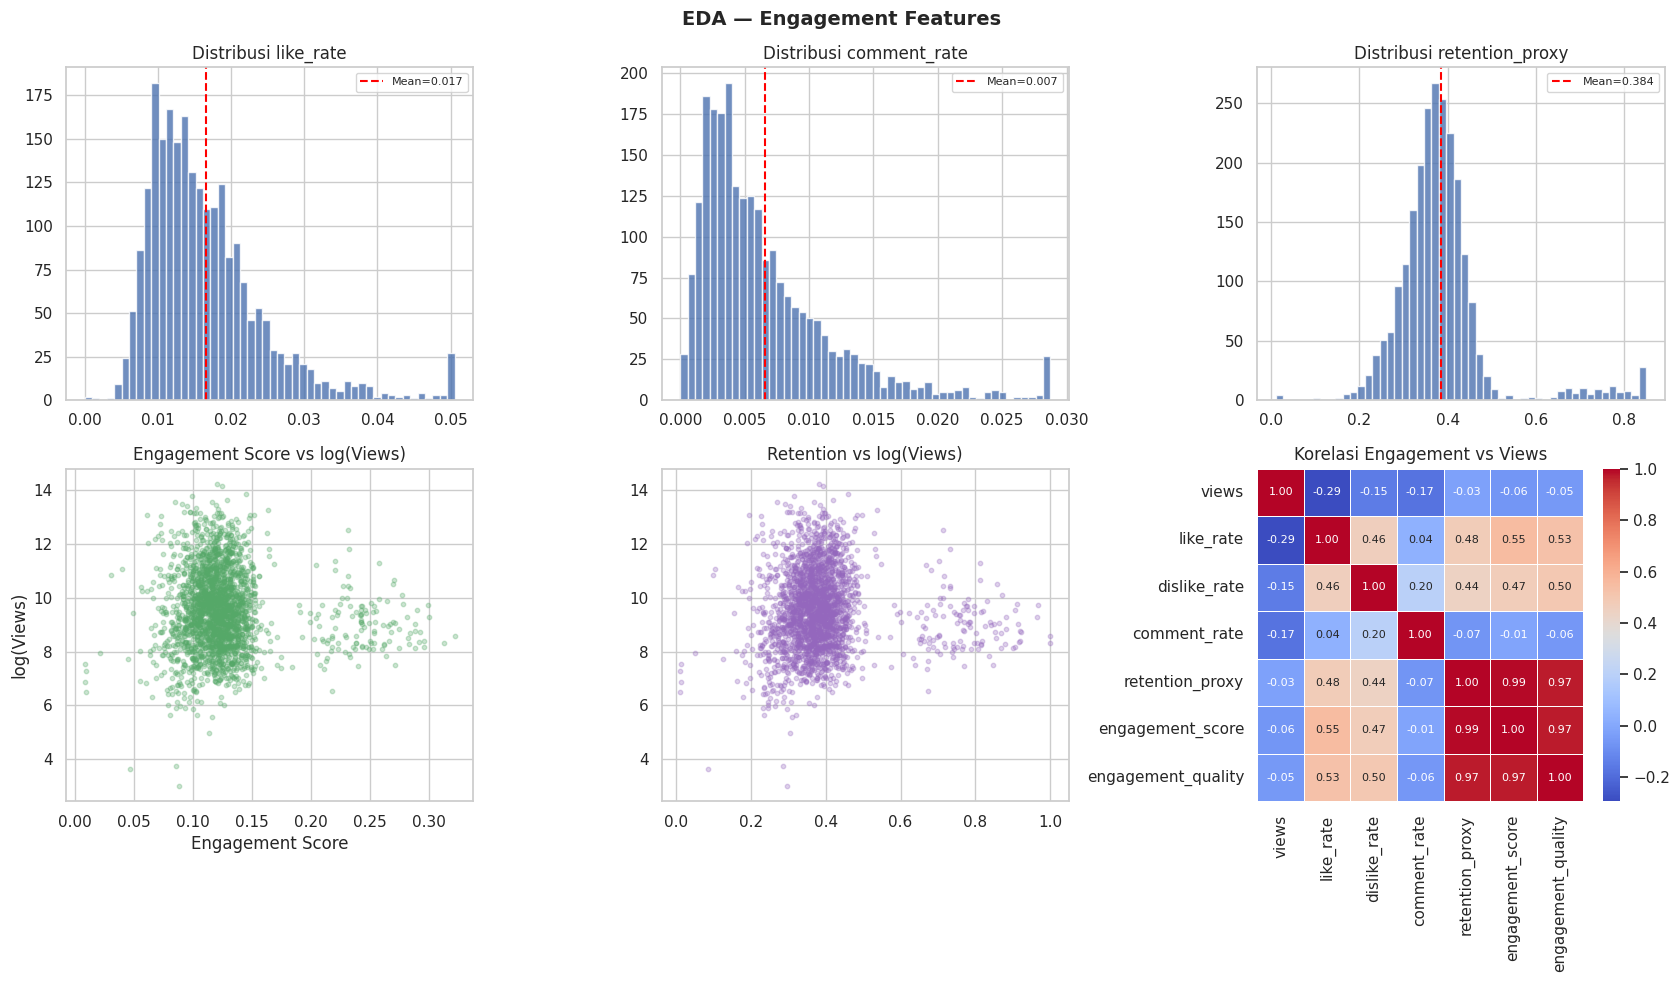

In [7]:
# ── 4. EDA FITUR ENGAGEMENT ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('EDA — Engagement Features', fontsize=14, fontweight='bold')

# (A) Distribution per metric
for ax, col in zip(axes[0], ['like_rate','comment_rate','retention_proxy']):
    vals = df[col].clip(0, df[col].quantile(0.99))
    ax.hist(vals, bins=50, color='#4C72B0', edgecolor='white', alpha=0.8)
    ax.set_title(f'Distribusi {col}')
    ax.axvline(vals.mean(), color='red', linestyle='--', label=f'Mean={vals.mean():.3f}')
    ax.legend(fontsize=8)

# (D) Engagement score vs views
axes[1][0].scatter(df['engagement_score'], np.log1p(df['views']),
                   alpha=0.3, s=10, color='#55A868')
axes[1][0].set_title('Engagement Score vs log(Views)')
axes[1][0].set_xlabel('Engagement Score')
axes[1][0].set_ylabel('log(Views)')

# (E) Retention proxy vs views
axes[1][1].scatter(df['retention_proxy'], np.log1p(df['views']),
                   alpha=0.3, s=10, color='#9467BD')
axes[1][1].set_title('Retention vs log(Views)')

# (F) Correlation heatmap
feat = ['views','like_rate','dislike_rate','comment_rate',
        'retention_proxy','engagement_score','engagement_quality']
corr = df[feat].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1][2],
            linewidths=0.5, annot_kws={'size':8})
axes[1][2].set_title('Korelasi Engagement vs Views')

plt.tight_layout()
plt.show()

In [8]:
# ── 5. VALIDASI & EXPORT ─────────────────────────────────────────────────────
eng_cols = [
    'video_id','like_rate','dislike_rate','comment_rate',
    'like_dislike_ratio','comment_engagement_ratio',
    'retention_proxy','engagement_score','engagement_quality'
]
df_out = df[eng_cols].copy()
df_out = df_out.replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"Shape: {df_out.shape}")
print(f"Nulls: {df_out.isnull().sum().sum()}")
display(df_out.head(3))

import os
output_path = '../../data/processed/features_engagement.csv'
os.makedirs(os.path.dirname(output_path), exist_ok=True)
df_out.to_csv(output_path, index=False)
print(f"\n✅ Tersimpan: {output_path}")

Shape: (2355, 9)
Nulls: 0


,video_id,like_rate,dislike_rate,comment_rate,like_dislike_ratio,comment_engagement_ratio,retention_proxy,engagement_score,engagement_quality
0,jkL6Ii5d4hI,0.010810,0.000234,0.001818,45.786408,0.168115,0.400369,0.124980,0.050038
1,mIeRGD4KT-A,0.011398,0.000198,0.003737,56.907895,0.327785,0.423290,0.132667,0.056157
2,XCRg3dGQqd8,0.012905,0.000215,0.002504,59.210526,0.193957,0.318182,0.101368,0.032253



✅ Tersimpan: ../../data/processed/features_engagement.csv
